<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/ASI_MarketRegime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What do we know about June seasonalty on the NGX?
## What are the best months on the NGX?

In [62]:
!pip install --upgrade yfinance
!pip install scipy==1.16.2
!pip install hurst -q

## Install Libraries

In [63]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
from datetime import datetime
import time
import random
import requests

import seaborn as sns
import matplotlib.pyplot as plt
from hurst import compute_Hc

from dataclasses import dataclass, field
from typing import Optional
import warnings
warnings.filterwarnings("ignore")
# ensure reproducibility
random.seed(42)
print("Libraries Installed!")

1.5.1
Libraries Installed!


## Estabish Market Regime

Calculating rolling Hurst...
Progress: 3100/3139 | Valid: 2951
Finished! Valid Hurst values: 2989/2989

Last 10 Days - Hurst, Alpha, K_Alpha, Regime & Adaptive EMAs
             Hurst   Alpha  K_Alpha                        Regime  \
2026-06-17  0.8038  0.3924   1.4115  Trending — Momentum Favoured   
2026-06-18  0.8116  0.3768   1.4348  Trending — Momentum Favoured   
2026-06-19  0.8233  0.3535   1.4698  Trending — Momentum Favoured   
2026-06-22  0.8294  0.3413   1.4881  Trending — Momentum Favoured   
2026-06-23  0.8405  0.3190   1.5215  Trending — Momentum Favoured   
2026-06-24  0.9151  0.1699   1.7452  Trending — Momentum Favoured   
2026-06-25  0.9021  0.1958   1.7063  Trending — Momentum Favoured   
2026-06-26  0.8704  0.2591   1.6113  Trending — Momentum Favoured   
2026-06-29  0.8650  0.2701   1.5949  Trending — Momentum Favoured   
2026-06-30  0.8466  0.3067   1.5399  Trending — Momentum Favoured   

            Fast_EMA_Len  Slow_EMA_Len  
2026-06-17            11          

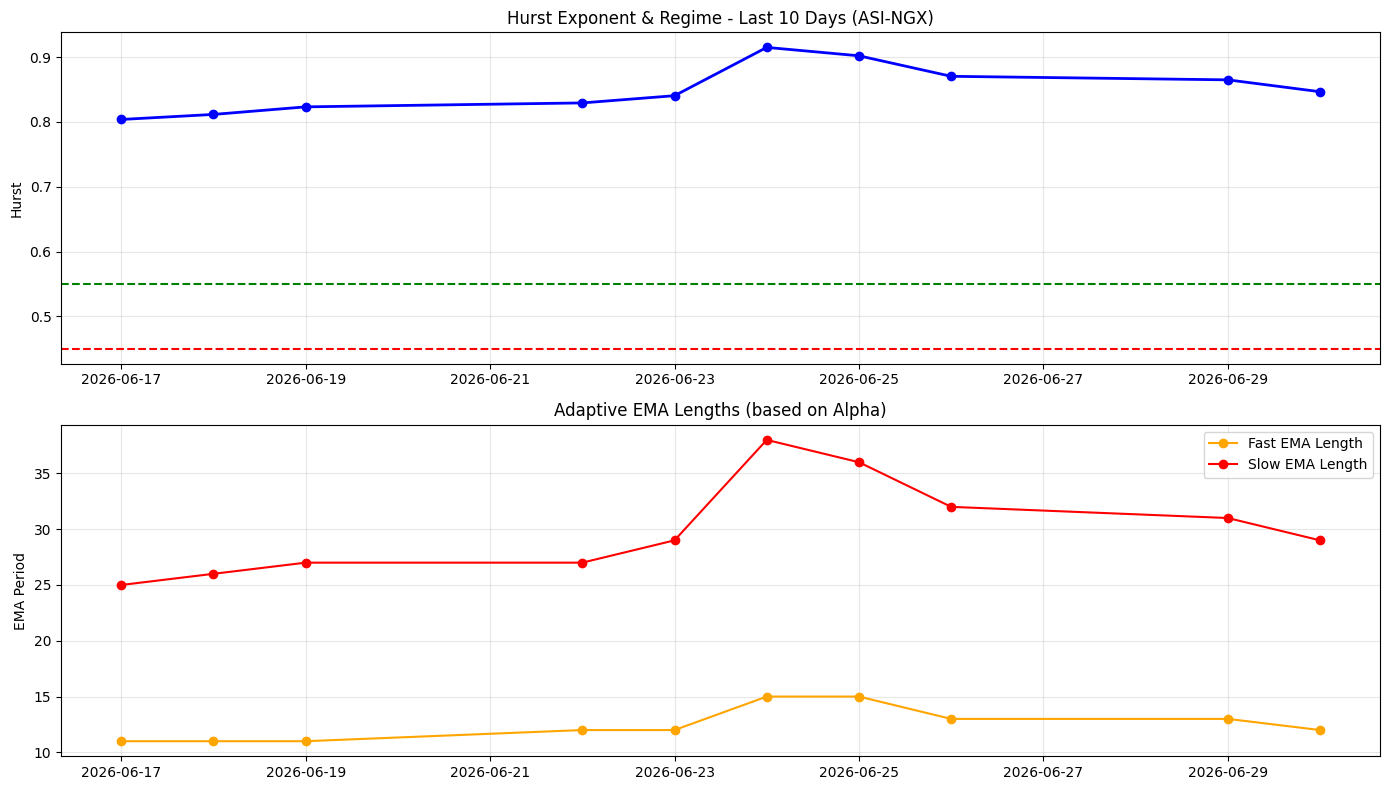

In [64]:

def get_prices():
     return (
        pd.read_csv('asi_data.csv')
        .assign(time=lambda x: pd.to_datetime(x["time"]))
        [["time", "close"]]
        .dropna()
        .set_index("time")
    )

def hurst_exponent(ts):
    ts = np.asarray(ts, dtype=float)
    if len(ts) < 100:
        return np.nan
    # Option A: Use log prices (common for indices)
    log_ts = np.log(ts)
    try:
        #H, _, _ = compute_Hc(ts, kind="price", simplified=True)
        H, _, _ = compute_Hc(log_ts, kind="price", simplified=True)
        return H
    except:
        return np.nan

def get_regime(h):
    if np.isnan(h):
        return "Unknown"
    elif h > 0.55:
        return "Trending — Momentum Favoured"
    elif h < 0.45:
        return "Mean Reverting — Counter-trend Favoured"
    else:
        return "Random Walk — Reduce Size"

# ====================== NEW FUNCTIONS ======================
def ema_length(alpha, n_min, n_max, k=2):
    """Convert market memory alpha into EMA length"""
    return n_min + (n_max - n_min) * (1 - alpha) ** k

def adaptive_ema_lengths(alpha):
    """Returns fast and slow EMA lengths"""
    fast = ema_length(alpha, n_min=5, n_max=20, k=2)
    slow = ema_length(alpha, n_min=10, n_max=50, k=2)
    return int(round(fast)), int(round(slow))

# ====================== ROLLING HURST ======================
def rolling_hurst(prices, window=150):
    hurst_vals = []
    dates = []
    valid = 0

    print("Calculating rolling Hurst...")

    for i in range(window, len(prices)):
        chunk = prices.iloc[i-window:i].values
        h = hurst_exponent(chunk)
        hurst_vals.append(h)
        dates.append(prices.index[i])

        if not np.isnan(h):
            valid += 1

        if i % 100 == 0:
            print(f"Progress: {i}/{len(prices)} | Valid: {valid}", end="\r")

    H = pd.Series(hurst_vals, index=dates, name="Hurst")
    print(f"\nFinished! Valid Hurst values: {valid}/{len(H)}")
    return H


# ====================== RUN ======================

prices = get_prices()

H = rolling_hurst(prices, window=150)
alpha = np.clip(2 - 2 * H, 0, 1)
k_alpha = 0.5 + 1.5*(1-alpha)

# Create main dataframe
df = pd.DataFrame({
    "Hurst": H,
    "Alpha": alpha,
    "K_Alpha": k_alpha,
    "Regime": H.apply(get_regime)
})

# Add Adaptive EMA Lengths
df['Fast_EMA_Len'], df['Slow_EMA_Len'] = zip(*df['Alpha'].apply(adaptive_ema_lengths))

# Calculate actual EMAs using adaptive lengths (using latest Alpha for simplicity)
latest_alpha = df['Alpha'].iloc[-1]
latest_Kalpha = df['K_Alpha'].iloc[-1]
fast_len, slow_len = adaptive_ema_lengths(latest_alpha)

#latest_Kalpha = 1
#fast_len, slow_len = 8, 15

df['Fast_EMA'] = prices.ewm(span=fast_len, adjust=False).mean()
df['Slow_EMA'] = prices.ewm(span=slow_len, adjust=False).mean()

# Last 10 days
last10 = df.dropna().tail(10)

print("\n" + "="*100)
print("Last 10 Days - Hurst, Alpha, K_Alpha, Regime & Adaptive EMAs")
print(last10[['Hurst', 'Alpha','K_Alpha', 'Regime', 'Fast_EMA_Len', 'Slow_EMA_Len']].round(4))

print(f"\nCurrent Adaptive EMAs (based on latest Alpha):")
print(f"Fast EMA Length : {fast_len}")
print(f"Slow EMA Length : {slow_len}")
print(f"Current Market Memory : {latest_alpha}")
print(f"Current k Alpha : {latest_Kalpha}")

# Plot
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(last10.index, last10["Hurst"], marker='o', color='blue', linewidth=2)
plt.axhline(0.55, color='green', linestyle='--')
plt.axhline(0.45, color='red', linestyle='--')
plt.title(f"Hurst Exponent & Regime - Last 10 Days (ASI-NGX)")
plt.ylabel("Hurst")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(last10.index, last10["Fast_EMA_Len"], marker='o', label='Fast EMA Length', color='orange')
plt.plot(last10.index, last10["Slow_EMA_Len"], marker='o', label='Slow EMA Length', color='red')
plt.title("Adaptive EMA Lengths (based on Alpha)")
plt.ylabel("EMA Period")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Start of Analysis

In [65]:
from dateutil.relativedelta import relativedelta



df =  pd.read_csv('asi_data.csv')




df["time"] = pd.to_datetime(df["time"])
df.set_index("time", inplace=True)
spy = df.copy()
start_date = df.index.min()
end_date = df.index.max()

rd = relativedelta(end_date, start_date)

years = rd.years
months = rd.months

trading_days = len(df)

print(f"Start Date : {start_date:%Y-%m-%d}")
print(f"End Date   : {end_date:%Y-%m-%d}")
print(f"Days       : {trading_days:,}")
print(f"Years      : {years:.2f}")


Start Date : 2013-09-30
End Date   : 2026-06-30
Days       : 3,139
Years      : 12.00


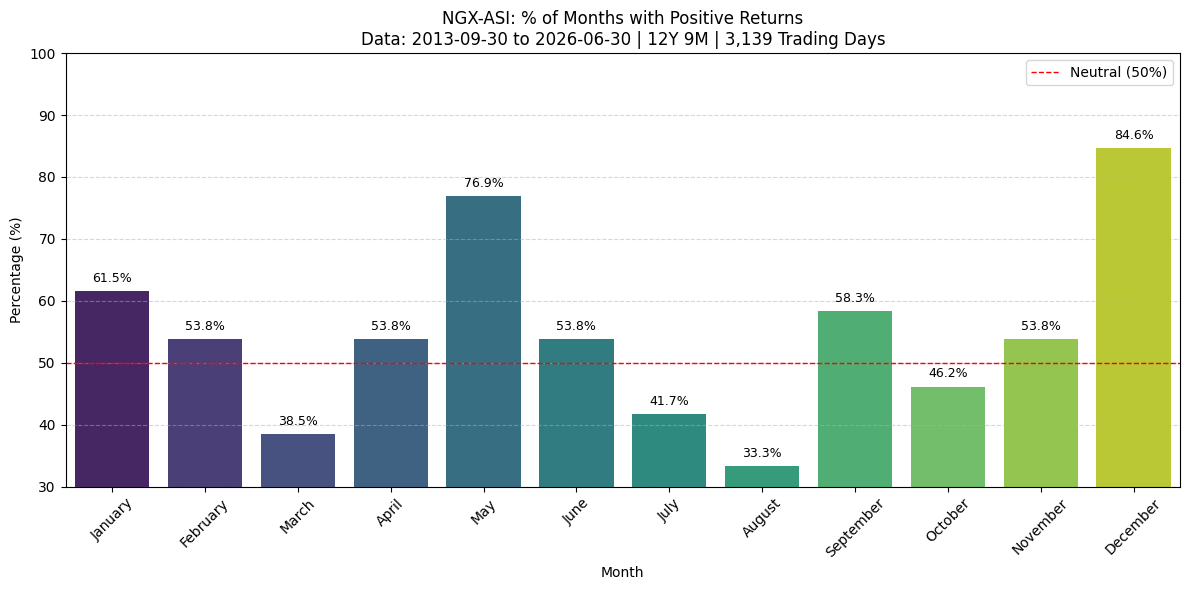

In [66]:

# Step 2: Resample to monthly data and calculate returns
ticker= 'NGX-ASI'
spy_monthly = spy['close'].resample('ME').last()
monthly_returns = spy_monthly.pct_change().dropna()


# Step 3: Extract month names and whether return was positive
# Step 3: Convert to DataFrame explicitly, then extract month info
monthly_returns_df = monthly_returns.to_frame(name='Return')
monthly_returns_df['Month'] = monthly_returns_df.index.month_name().to_list()  # FIX #2 — .to_list() avoids index-alignment ambiguity
monthly_returns_df['Positive'] = monthly_returns_df['Return'] > 0


# Step 4: Group by month and calculate percent positive
positive_rate = (
    monthly_returns_df.groupby('Month')['Positive']
    .mean()
    .rename("Percent Positive")
    .mul(100)
    .reset_index()
)

# Step 5: Order months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
positive_rate['Month'] = pd.Categorical(
    positive_rate['Month'], categories=month_order, ordered=True
)
positive_rate = positive_rate.sort_values('Month').reset_index(drop=True)

# Step 6: Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=positive_rate,
    x='Month',
    y='Percent Positive',
    hue='Month',
    palette='viridis',
    legend=False
)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

plt.axhline(50, color='red', linestyle='--', linewidth=1, label='Neutral (50%)')
plt.legend()
plt.xticks(rotation=45)
plt.title(
    f"{ticker}: % of Months with Positive Returns\n"
    f"Data: {start_date:%Y-%m-%d} to {end_date:%Y-%m-%d} | "
    f"{years}Y {months}M | {trading_days:,} Trading Days"
)
plt.ylabel("Percentage (%)")
plt.ylim(30, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)  # alpha=1.0 makes grid lines fully opaque and distracting
plt.tight_layout()
plt.show()

In [67]:
# Ensure datetime index
df = monthly_returns_df.copy()
df.index = pd.to_datetime(df.index)

# Extract year
df["year"] = df.index.year

# Filter June only
june_df = df[df.index.month == 6].copy()

# Convert to %
june_df["return_pct"] = june_df["Return"] * 100

june_df

,Return,Month,Positive,year,return_pct
time,,,,,
2014-06-30,0.024306,June,True,2014,2.430649
2015-06-30,-0.024877,June,False,2015,-2.487711
2016-06-30,0.069629,June,True,2016,6.962898
2017-06-30,0.122691,June,True,2017,12.269072
2018-06-30,0.004567,June,True,2018,0.456670
2019-06-30,-0.035485,June,False,2019,-3.548511
2020-06-30,-0.031212,June,False,2020,-3.121203
2021-06-30,-0.013804,June,False,2021,-1.380404
2022-06-30,-0.033923,June,False,2022,-3.392334


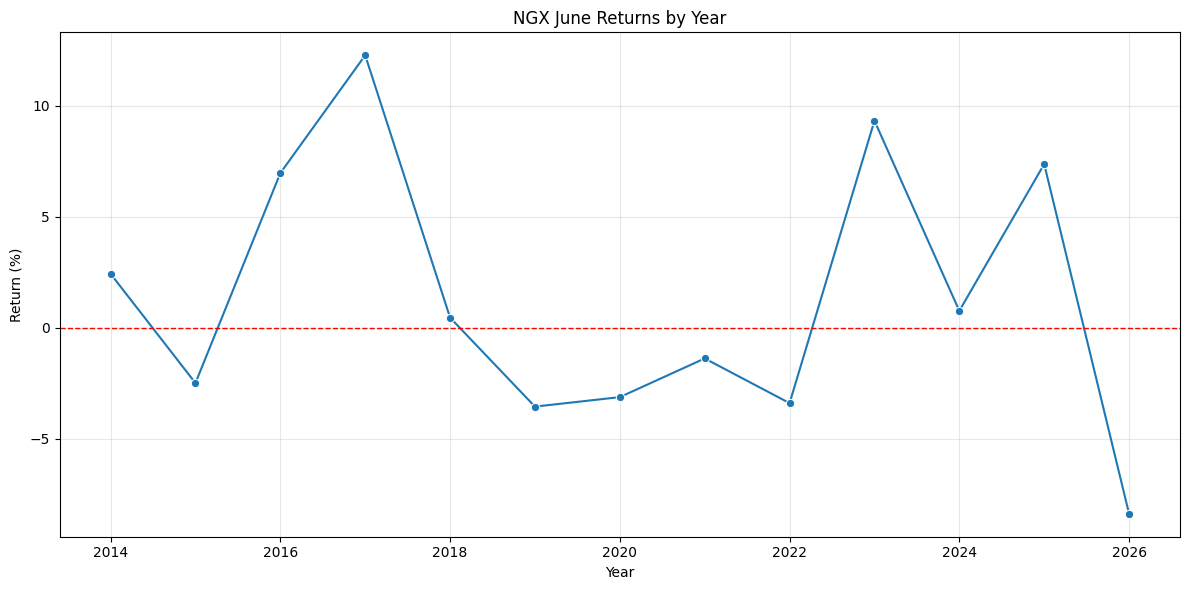

In [68]:
# Sort by year
june_df = june_df.sort_values("year")

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=june_df,
    x="year",
    y="return_pct",
    marker="o"
)

plt.axhline(0, color="red", linestyle="--", linewidth=1)

plt.title("NGX June Returns by Year")
plt.ylabel("Return (%)")
plt.xlabel("Year")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [69]:
historical_junes = june_df.iloc[:-1]["return_pct"]
current_june_return = june_df.iloc[-1]["return_pct"]

#current_june_return
historical_junes

,return_pct
time,
2014-06-30,2.430649
2015-06-30,-2.487711
2016-06-30,6.962898
2017-06-30,12.269072
2018-06-30,0.456670
2019-06-30,-3.548511
2020-06-30,-3.121203
2021-06-30,-1.380404
2022-06-30,-3.392334


In [70]:
#current_june_return = june_df.iloc[-1]["return_pct"]  # example: -8.37%
historical_junes = june_df.iloc[:-1]["return_pct"]
current_june_return = june_df.iloc[-1]["return_pct"]

mean = historical_junes.mean()
std = historical_junes.std()

z_score = (current_june_return - mean) / std

percentile_rank = (historical_junes < current_june_return).mean() * 100

print(f"Current June Return: {current_june_return:.2f}%")
print(f"Mean Historical June: {mean:.2f}%")
print(f"Std Dev: {std:.2f}%")
print(f"Z-Score: {z_score:.2f}")
print(f"Percentile Rank: {percentile_rank:.2f}%")

if percentile_rank <= 20:
    interpretation = "🟢 Normal June behavior"

elif percentile_rank <= 50:
    interpretation = "🟡 Mild weakness vs history"

elif percentile_rank <= 80:
    interpretation = "🟠 Strong June weakness"

elif percentile_rank <= 95:
    interpretation = "🔴 Severe June stress event"

else:
    interpretation = "🚨 Extreme tail-risk June event"

print(interpretation)

Current June Return: -8.37%
Mean Historical June: 2.14%
Std Dev: 5.51%
Z-Score: -1.91
Percentile Rank: 0.00%
🟢 Normal June behavior


## Hypothesis: June is the worst performing month on the NGX market?If yes, what is the average pullback in June. The median etc.
Is the current pullback/correction typical ? What percentile is the current June pullback rank ?

In [71]:
monthly_returns_df.iloc[:-1]

,Return,Month,Positive
time,,,
2013-10-31,0.028363,October,True
2013-11-30,0.034503,November,True
2013-12-31,0.061878,December,True
2014-01-31,-0.018330,January,False
2014-02-28,-0.024962,February,False
...,...,...,...
2026-01-31,0.062703,January,True
2026-02-28,0.166030,February,True
2026-03-31,0.043879,March,True


In [72]:
# June Performance Stats
monthly_returns_df2 = monthly_returns_df.iloc[:-1].copy()
june_returns = monthly_returns_df2[monthly_returns_df2["Month"] == "June"]["Return"]

june_stats = {
    "mean return": june_returns.mean(),
    "median return": june_returns.median(),
    "std": june_returns.std(),
    "mininimum return": june_returns.min(),
    "max return": june_returns.max(),
    "count": june_returns.count()
}

june_stats

{'mean return': np.float64(0.02137058025858411),
 'median return': 0.006094368639275594,
 'std': 0.05510975767586587,
 'mininimum return': -0.0354851107532953,
 'max return': 0.12269071947882049,
 'count': np.int64(12)}

In [73]:
# Is June the worst month?
monthly_avg = monthly_returns_df2.groupby("Month")["Return"].mean() * 100

# Order correctly
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_avg = monthly_avg.reindex(month_order)

print(monthly_avg.sort_values())

Month
March       -1.190315
August      -0.515663
October      0.045373
July         0.080971
November     0.475536
February     0.824134
September    0.973867
April        2.136760
June         2.137058
January      3.530569
December     4.513884
May          4.704930
Name: Return, dtype: float64


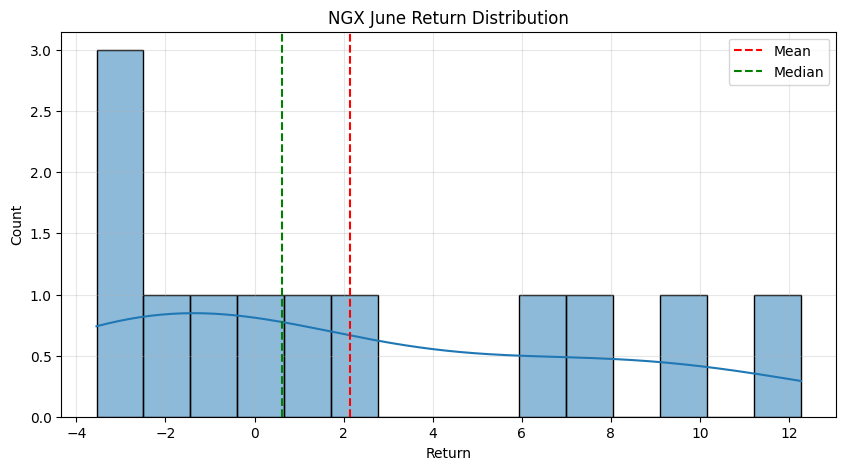

In [74]:
# Distribution of June returns
plt.figure(figsize=(10,5))

sns.histplot(june_returns * 100, bins=15, kde=True)

plt.axvline(june_returns.mean()*100, color="red", linestyle="--", label="Mean")
plt.axvline(june_returns.median()*100, color="green", linestyle="--", label="Median")

plt.title("NGX June Return Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [75]:
worst_month = monthly_avg.sort_values().index[0]

print("Worst performing month:", worst_month)
print("June rank:", monthly_avg.rank().loc["June"])

Worst performing month: March
June rank: 9.0


In [76]:
# “Seasonal Stress Index”
z_score = (current_june_return - june_returns.mean()) / june_returns.std()

z_score

np.float64(-152.33338002129628)

## Best performing day of week on the NGX

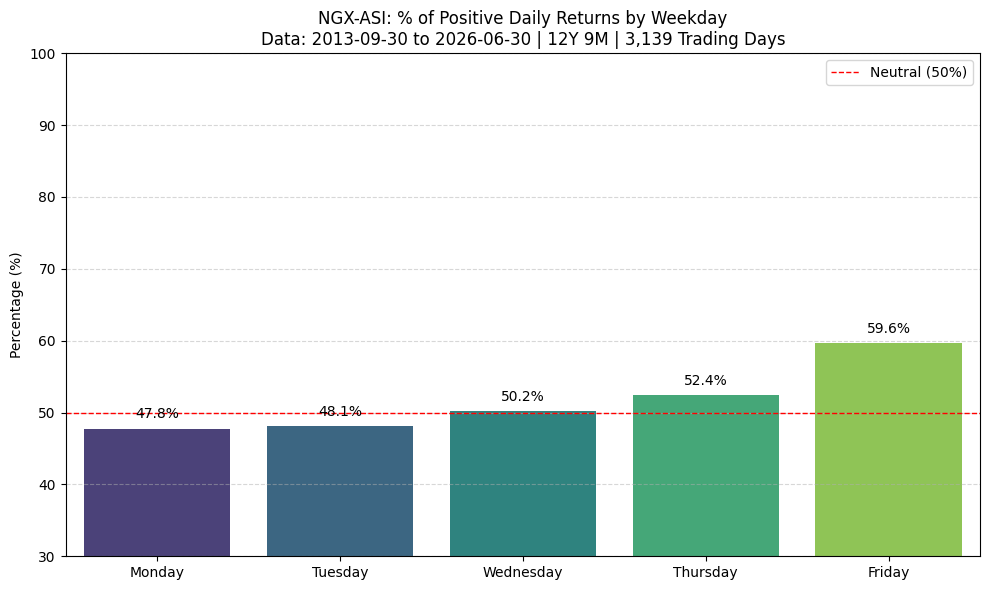

In [77]:
# ============================================
# Daily Returns by Weekday
# ============================================

ticker = "NGX-ASI"

# Step 1: Calculate daily returns
daily_returns = spy["close"].pct_change().dropna()

# Step 2: Convert to DataFrame
daily_returns_df = daily_returns.to_frame(name="Return")

# Step 3: Extract weekday names
daily_returns_df["Weekday"] = daily_returns_df.index.day_name()

# Step 4: Flag positive returns
daily_returns_df["Positive"] = daily_returns_df["Return"] > 0

# Step 5: Calculate % positive by weekday
positive_rate = (
    daily_returns_df.groupby("Weekday")["Positive"]
    .mean()
    .mul(100)
    .rename("Percent Positive")
    .reset_index()
)

# Step 6: Order weekdays
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday"
]

positive_rate["Weekday"] = pd.Categorical(
    positive_rate["Weekday"],
    categories=weekday_order,
    ordered=True
)

positive_rate = positive_rate.sort_values("Weekday").reset_index(drop=True)

# Step 7: Plot
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=positive_rate,
    x="Weekday",
    y="Percent Positive",
    hue="Weekday",
    palette="viridis",
    legend=False
)

# Labels
for bar in ax.patches:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.axhline(
    50,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Neutral (50%)"
)

plt.legend()

plt.title(
    f"{ticker}: % of Positive Daily Returns by Weekday\n"
    f"Data: {start_date:%Y-%m-%d} to {end_date:%Y-%m-%d} | "
    f"{years}Y {months}M | {trading_days:,} Trading Days"
)

plt.ylabel("Percentage (%)")
plt.xlabel("")
plt.ylim(30,100)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()